In [1]:
import os
import sys
import h5py
import numpy as np
import matplotlib.pyplot as plt

sys.path.append(os.path.abspath(".."))

from toolbox_mingyang import *

f = h5py.File("../data/SimuData.mat", "r")

Image = f["Image"][:]
img = Image['real'] + 1j * Image['imag']

kspace = fft2c_mingyang(img)

Nsh, Npe, Nro = kspace.shape
mask = np.zeros((Nsh, Nro, Npe))

for nsh in range(Nsh):
    mask[nsh, nsh::Nsh, :] = 1

Undersampling_kspace = mask * kspace



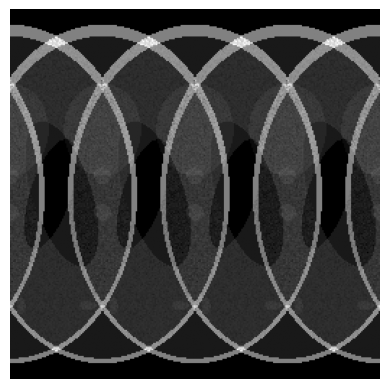

In [3]:
Aliasing_img = ifft2c_mingyang(Undersampling_kspace)
show_mri(Aliasing_img[1], "mag")